In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Crop_recommendation.csv") 
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print(df.shape)

(2200, 8)


In [4]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [6]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool


In [7]:
print(df.describe())

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  


# Data Explorating

In [9]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

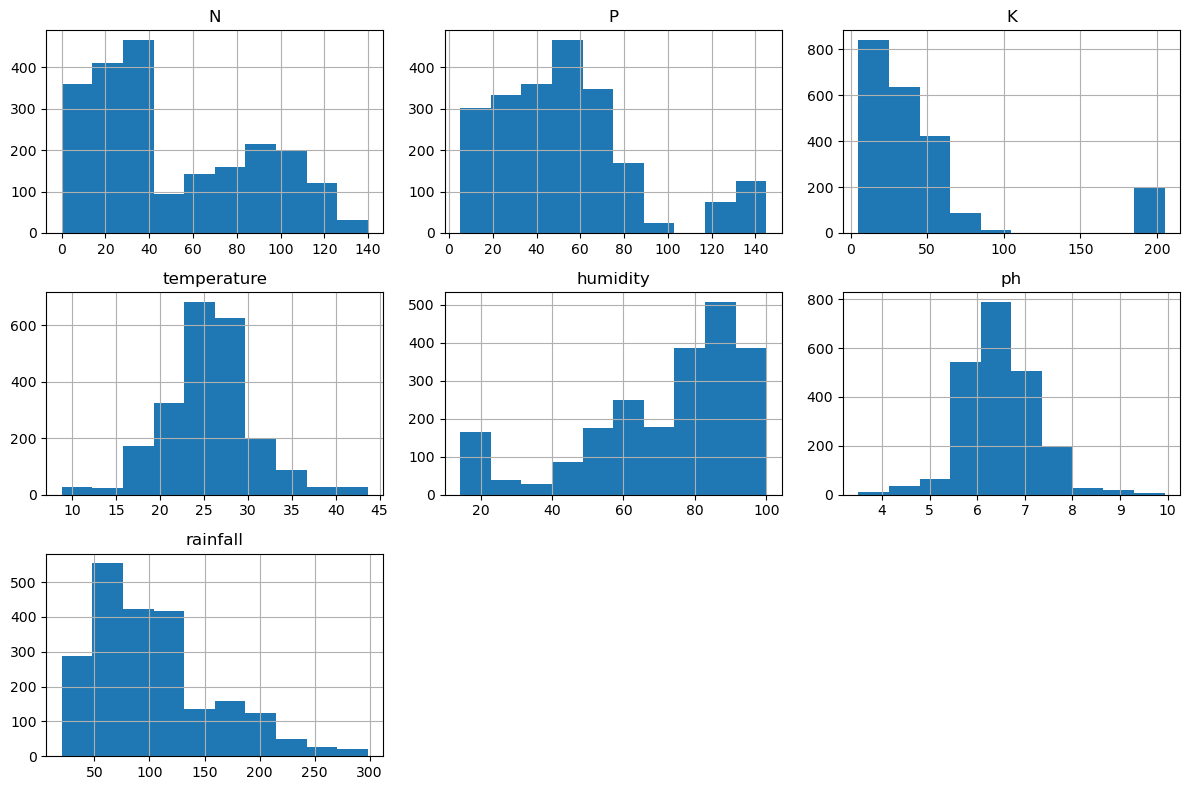

In [10]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Encoding

In [12]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [13]:
crop_dict = {
"rice":1,
"maize":2,
"jute":3,
"cotton": 4,
"coconut": 5,
"papaya": 6,
"orange":  7,
"apple"  :8,
"muskmelon": 9,
"watermelon":10,
"grapes" : 11,
"mango":   12,
"banana":  13,
"pomegranate": 14,
"lentil": 15,
"blackgram":16,
"mungbean": 17,
"mothbeans": 18,
"pigeonpeas":19,
"kidneybeans":20,
"chickpea":21,
"coffee":22,
}
df["crop_names"]= df["label"].map(crop_dict)


In [14]:
df["crop_names"].value_counts()

crop_names
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
Name: count, dtype: int64

In [15]:
df.drop("label",axis = 1,inplace=True)

In [16]:
df

,N,P,K,temperature,humidity,ph,rainfall,crop_names
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,22


# Train_Test

In [18]:
x = df.drop("crop_names",axis =1)
y = df["crop_names"]

In [19]:
x.shape

(2200, 7)

In [20]:
y.shape

(2200,)

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2,random_state=42)

In [22]:
x_train.shape

(1760, 7)

In [23]:
y_train.shape

(1760,)

In [24]:
x_test.shape

(440, 7)

# Scale the Features using MinMaxScaler

In [26]:
from sklearn.preprocessing import MinMaxScaler
mc = MinMaxScaler()
x_train = mc.fit_transform(x_train)
x_test = mc.fit_transform(x_test)

In [27]:
x_train

array([[0.12142857, 0.07857143, 0.045     , ..., 0.9089898 , 0.48532225,
        0.29685161],
       [0.26428571, 0.52857143, 0.07      , ..., 0.64257946, 0.56594073,
        0.17630752],
       [0.05      , 0.48571429, 0.1       , ..., 0.57005802, 0.58835229,
        0.08931844],
       ...,
       [0.07857143, 0.22142857, 0.13      , ..., 0.43760347, 0.46198144,
        0.28719815],
       [0.07857143, 0.85      , 0.995     , ..., 0.76763665, 0.44420505,
        0.18346657],
       [0.22857143, 0.52142857, 0.085     , ..., 0.56099735, 0.54465022,
        0.11879596]])

In [28]:
x_test.shape

(440, 7)

# StandardScaler

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [31]:
x_train

array([[-9.03426596e-01, -1.12616170e+00, -6.68506601e-01, ...,
         9.36586183e-01,  1.93473784e-01,  5.14970176e-03],
       [-3.67051340e-01,  7.70358846e-01, -5.70589522e-01, ...,
        -1.00470485e-01,  8.63917548e-01, -6.05290566e-01],
       [-1.17161422e+00,  5.89737842e-01, -4.53089028e-01, ...,
        -3.82774991e-01,  1.05029771e+00, -1.04580687e+00],
       ...,
       [-1.06433917e+00, -5.24091685e-01, -3.35588533e-01, ...,
        -8.98381379e-01, -6.34357580e-04, -4.37358211e-02],
       [-1.06433917e+00,  2.12501638e+00,  3.05234239e+00, ...,
         3.86340190e-01, -1.48467347e-01, -5.69036842e-01],
       [-5.01145154e-01,  7.40255346e-01, -5.11839275e-01, ...,
        -4.18045489e-01,  6.86860180e-01, -8.96531475e-01]])

# Training Models

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import ExtraTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import  BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score

models = {
    "LogisticRegression":LogisticRegression(),
    "SVC":SVC(),
    "ExtraTreeClassifier":ExtraTreeClassifier(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "BaggingClassifier":BaggingClassifier(),
    "KNeighborsClassifier":KNeighborsClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier(),
    "GradientBoostingClassifier":GradientBoostingClassifier(),
}
for name, md in models.items():
    md.fit(x_train,y_train)
    y_pred = md.predict(x_test)
    print(f"{name} with Accuracy: {accuracy_score(y_test,y_pred)}")

LogisticRegression with Accuracy: 0.9545454545454546
SVC with Accuracy: 0.9590909090909091
ExtraTreeClassifier with Accuracy: 0.9
DecisionTreeClassifier with Accuracy: 0.9477272727272728
RandomForestClassifier with Accuracy: 0.9818181818181818
BaggingClassifier with Accuracy: 0.9272727272727272
KNeighborsClassifier with Accuracy: 0.9431818181818182


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier with Accuracy: 0.09545454545454546
GradientBoostingClassifier with Accuracy: 0.9295454545454546


In [34]:
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred = rfc.predict(x_test)
print("RandomForest Accuracy_score is : ",accuracy_score(y_test,y_pred))


RandomForest Accuracy_score is :  0.9795454545454545


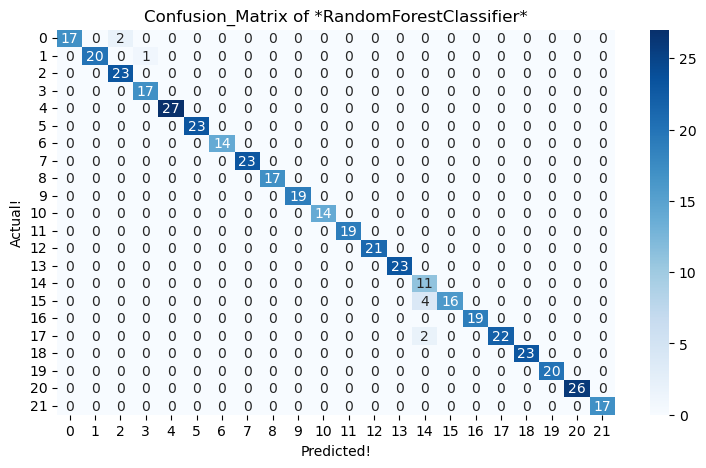

In [35]:
import seaborn as sns
plt.figure(figsize = (9,5))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot = True,fmt="d",cmap="Blues")
plt.title("Confusion_Matrix of *RandomForestClassifier*")
plt.xlabel("Predicted!")
plt.ylabel("Actual!")
plt.show()

# Predictive System

In [37]:
def recommendation(N, P, K, temperature, humidity, ph, rainfall):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])  # 2D array
    prediction = rfc.predict(features)
    return prediction[0]


# Input values
N = 30
P = 20
K = 90
temperature = 30
humidity = 90
ph = 67
rainfall = 100

# Predict crop
predict = recommendation(N, P, K, temperature, humidity, ph, rainfall)

crop_dict = {
    1: "rice", 2: "maize", 3: "jute", 4: "cotton", 5: "coconut", 6: "papaya",
    7: "orange", 8: "apple", 9: "muskmelon", 10: "watermelon", 11: "grapes", 12: "mango",
    13: "banana", 14: "pomegranate", 15: "lentil", 16: "blackgram", 17: "mungbean", 
    18: "mothbeans", 19: "pigeonpeas", 20: "kidneybeans", 21: "chickpea", 22: "coffee"
}

# Output prediction
if predict in crop_dict:
    df = crop_dict[predict]
    print(f"{df} is the best crop for cultivated!")
else:
    print("Sorry are not able to recommend a proper crop for this environment.")


apple is the best crop for cultivated!


# -------------------------------
# Project Completed by Sajjad Hussain
# -------------------------------


In [72]:
import pickle 
pickle.dump(rfc,open("Crop_Recommendation_App.pkl","wb"))